# LocoSense — Phase 2: Preprocessing & Feature Engineering

**Input:** `data/processed/locosense_phase1.csv`  
**Output:** `data/processed/train.csv`, `val.csv`, `test.csv`

| Step | Task |
|------|------|
| 1 | Load Phase 1 output |
| 2 | Fix data types |
| 3 | Handle `days_since_service` negatives |
| 4 | Add `loco_age` feature |
| 5 | Rolling features (mean & std, windows 5 & 10) |
| 6 | Lag features (previous cycle sensor values) |
| 7 | One-hot encode `loco_type` and `zone` |
| 8 | Train / Val / Test split (by loco_id) |
| 9 | Normalize sensor columns (MinMaxScaler) |
| 10 | Save outputs + summary |

---
## Cell 1 — Imports

In [1]:
import sys, warnings, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

NOTEBOOK_DIR  = Path().resolve()
ROOT          = NOTEBOOK_DIR.parent
PROCESSED_DIR = ROOT / 'data' / 'processed'
FIGURES_DIR   = ROOT / 'reports' / 'figures'
MODELS_DIR    = ROOT / 'models'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV = PROCESSED_DIR / 'locosense_phase1.csv'
assert INPUT_CSV.exists(), f'Run 01_setup_and_eda.ipynb first — {INPUT_CSV} not found.'

SENSOR_COLS = [
    'engine_temp', 'oil_pressure', 'vibration', 'fuel_efficiency',
    'coolant_temp', 'bearing_temp', 'rpm', 'exhaust_temp',
    'turbo_pressure', 'load_factor', 'battery_voltage', 'brake_pressure',
]

print(f'Python  : {sys.version.split()[0]}')
print(f'pandas  : {pd.__version__}')
print(f'sklearn : {__import__("sklearn").__version__}')
print('Imports OK ✓')

Python  : 3.13.1
pandas  : 3.0.3
sklearn : 1.9.0
Imports OK ✓


---
## Cell 2 — Load Phase 1 output

In [2]:
df = pd.read_csv(INPUT_CSV)
print(f'Loaded : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Locos  : {df["loco_id"].nunique()}')
df.head(3)

Loaded : 6,925 rows x 22 columns
Locos  : 50


,loco_id,loco_type,zone,manufacture_year,cycle,total_cycles,days_since_service,engine_temp,oil_pressure,vibration,...,bearing_temp,rpm,exhaust_temp,turbo_pressure,load_factor,battery_voltage,brake_pressure,ru,failure_label,risk_category
0,WDG4-1001,WDG4,NR,2014,1,174,-12,78.563,3.379,1.993,...,59.894,917.562,323.872,2.033,76.166,24.098,4.137,173,0,Low
1,WDG4-1001,WDG4,NR,2014,2,174,-10,83.015,3.785,2.354,...,59.337,913.649,325.032,1.775,70.422,23.585,3.951,172,0,Low
2,WDG4-1001,WDG4,NR,2014,3,174,-8,81.256,3.553,1.808,...,63.438,881.074,318.182,1.891,64.320,24.109,4.280,171,0,Low


---
## Cell 3 — Fix data types

In [3]:
df['failure_label']    = df['failure_label'].astype(int)
df['manufacture_year'] = df['manufacture_year'].astype(int)
df['cycle']            = df['cycle'].astype(int)
df['total_cycles']     = df['total_cycles'].astype(int)

RISK_MAP = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df['risk_encoded'] = df['risk_category'].map(RISK_MAP)

print('Dtypes fixed:')
for col in ['failure_label', 'manufacture_year', 'cycle', 'total_cycles', 'risk_encoded']:
    print(f'  {col:<22} {df[col].dtype}')
print('\nfailure_label distribution:')
print(df['failure_label'].value_counts().to_string())

Dtypes fixed:
  failure_label          int64
  manufacture_year       int64
  cycle                  int64
  total_cycles           int64
  risk_encoded           int64

failure_label distribution:
failure_label
0    5375
1    1550


---
## Cell 4 — Handle `days_since_service` negatives

441 rows have negative values (range -38 to 0). Decision: keep as-is — negatives represent days *before* next scheduled service, which is genuine signal.

Negative rows : 441
Range         : -38 to 180
Decision      : KEEP negatives (pre-service window signal)


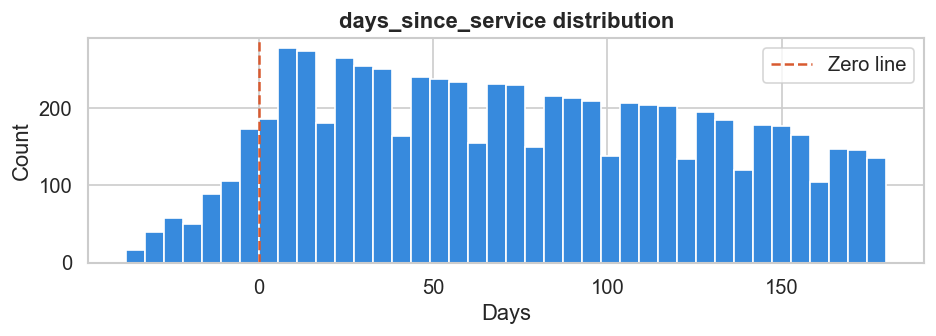

In [4]:
neg_count = (df['days_since_service'] < 0).sum()
print(f'Negative rows : {neg_count}')
print(f'Range         : {df["days_since_service"].min():.0f} to {df["days_since_service"].max():.0f}')
print('Decision      : KEEP negatives (pre-service window signal)')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(df['days_since_service'], bins=40, color='#378ADD', edgecolor='white')
ax.axvline(0, color='#D85A30', linestyle='--', linewidth=1.5, label='Zero line')
ax.set_title('days_since_service distribution', fontweight='bold')
ax.set_xlabel('Days')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'days_since_service_dist.png')
plt.show()

---
## Cell 5 — Add `loco_age` feature

In [5]:
CURRENT_YEAR = 2024
df['loco_age'] = CURRENT_YEAR - df['manufacture_year']
print('loco_age stats:')
print(df['loco_age'].describe().round(1).to_string())
print()
print(df[['loco_id','manufacture_year','loco_age']].drop_duplicates('loco_id').head(5).to_string(index=False))

loco_age stats:
count    6925.0
mean        9.0
std         3.4
min         4.0
25%         6.0
50%         9.0
75%        12.0
max        14.0

  loco_id  manufacture_year  loco_age
WDG4-1001              2014        10
WAP7-1002              2011        13
WDG4-1003              2010        14
WDG4-1004              2018         6
WDG4-1005              2020         4


---
## Cell 6 — Rolling features (windows 5 & 10 cycles)

Rolling mean and std capture sensor *trends* over time — biggest accuracy booster for predictive maintenance. Computed per loco so values never bleed across locomotives.

In [6]:
df = df.sort_values(['loco_id', 'cycle']).reset_index(drop=True)

WINDOWS = [5, 10]
rolling_cols_added = []

for window in WINDOWS:
    for sensor in SENSOR_COLS:
        mean_col = f'{sensor}_roll{window}_mean'
        std_col  = f'{sensor}_roll{window}_std'
        grp = df.groupby('loco_id')[sensor]
        df[mean_col] = grp.transform(lambda x: x.rolling(window, min_periods=1).mean())
        df[std_col]  = grp.transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
        rolling_cols_added.extend([mean_col, std_col])

print(f'Rolling features added : {len(rolling_cols_added)}')
print(f'  ({len(SENSOR_COLS)} sensors x {len(WINDOWS)} windows x 2 stats)')
print(f'Total columns now      : {df.shape[1]}')

sample_loco = df['loco_id'].iloc[0]
print(f'\nSample loco {sample_loco} — first 5 cycles:')
print(df[df['loco_id']==sample_loco][['cycle','engine_temp','engine_temp_roll5_mean','engine_temp_roll10_std']].head(5).to_string(index=False))

Rolling features added : 48
  (12 sensors x 2 windows x 2 stats)
Total columns now      : 72

Sample loco WAG9-1006 — first 5 cycles:
 cycle  engine_temp  engine_temp_roll5_mean  engine_temp_roll10_std
     1       86.259                86.25900                0.000000
     2       84.101                85.18000                1.525936
     3       81.694                84.01800                2.283632
     4       83.031                83.77125                1.928780
     5       81.834                83.38380                1.881683


---
## Cell 7 — Lag features (1 cycle back)

In [7]:
lag_cols_added = []
for sensor in SENSOR_COLS:
    lag_col = f'{sensor}_lag1'
    df[lag_col] = df.groupby('loco_id')[sensor].transform(lambda x: x.shift(1))
    df[lag_col] = df[lag_col].fillna(df[sensor])   # first cycle: use current value
    lag_cols_added.append(lag_col)

print(f'Lag features added : {len(lag_cols_added)}')
print(f'Total columns now  : {df.shape[1]}')
print(f'Null check         : {df[lag_cols_added].isnull().sum().sum()} nulls')

print(f'\nSample loco {sample_loco} — first 4 cycles:')
print(df[df['loco_id']==sample_loco][['cycle','engine_temp','engine_temp_lag1']].head(4).to_string(index=False))

Lag features added : 12
Total columns now  : 84
Null check         : 0 nulls

Sample loco WAG9-1006 — first 4 cycles:
 cycle  engine_temp  engine_temp_lag1
     1       86.259            86.259
     2       84.101            86.259
     3       81.694            84.101
     4       83.031            81.694


---
## Cell 8 — One-hot encode `loco_type` and `zone`

In [8]:
df = pd.get_dummies(df, columns=['loco_type', 'zone'], drop_first=False, dtype=int)
new_ohe_cols = [c for c in df.columns if c.startswith('loco_type_') or c.startswith('zone_')]
print(f'One-hot columns added : {len(new_ohe_cols)}')
for c in new_ohe_cols:
    print(f'  {c}  (sum={df[c].sum()})')
print(f'\nTotal columns now : {df.shape[1]}')

One-hot columns added : 10
  loco_type_WAG9  (sum=1043)
  loco_type_WAP5  (sum=1962)
  loco_type_WAP7  (sum=1530)
  loco_type_WDG4  (sum=1229)
  loco_type_WDP4B  (sum=1161)
  zone_CR  (sum=1282)
  zone_ER  (sum=2043)
  zone_NR  (sum=1639)
  zone_SR  (sum=715)
  zone_WR  (sum=1246)

Total columns now : 92


---
## Cell 9 — Train / Val / Test split by loco_id

**Why by loco_id?** Splitting randomly lets cycles from the same loco appear in train AND test — model memorises loco-specific patterns, accuracy looks inflated. Split by loco = true out-of-sample test.

| Split | Locos | % |
|-------|-------|---|
| Train | 35 | 70% |
| Val | 7 | 15% |
| Test | 8 | 15% |

In [9]:
random.seed(42)
all_locos = df['loco_id'].unique().tolist()
random.shuffle(all_locos)

n_total = len(all_locos)
n_train = int(n_total * 0.70)
n_val   = int(n_total * 0.15)

train_locos = all_locos[:n_train]
val_locos   = all_locos[n_train : n_train + n_val]
test_locos  = all_locos[n_train + n_val :]

train_df = df[df['loco_id'].isin(train_locos)].copy()
val_df   = df[df['loco_id'].isin(val_locos)].copy()
test_df  = df[df['loco_id'].isin(test_locos)].copy()

print(f'Train : {len(train_locos)} locos  {len(train_df):,} rows  {train_df["failure_label"].mean()*100:.1f}% failure')
print(f'Val   : {len(val_locos)} locos   {len(val_df):,} rows  {val_df["failure_label"].mean()*100:.1f}% failure')
print(f'Test  : {len(test_locos)} locos   {len(test_df):,} rows  {test_df["failure_label"].mean()*100:.1f}% failure')

assert not set(train_locos) & set(val_locos)
assert not set(train_locos) & set(test_locos)
assert not set(val_locos)   & set(test_locos)
print('\nNo loco leaks across splits ✓')

Train : 35 locos  4,979 rows  21.8% failure
Val   : 7 locos   802 rows  27.1% failure
Test  : 8 locos   1,144 rows  21.7% failure

No loco leaks across splits ✓


---
## Cell 10 — Normalize with MinMaxScaler

Fit on **train only** — transform val & test. Fitting on all data leaks test distribution into training.

In [10]:
scale_cols = SENSOR_COLS + rolling_cols_added + lag_cols_added + ['loco_age', 'days_since_service', 'ru']

scaler = MinMaxScaler()
train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
val_df[scale_cols]   = scaler.transform(val_df[scale_cols])
test_df[scale_cols]  = scaler.transform(test_df[scale_cols])

joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
print(f'Scaled {len(scale_cols)} columns')
print(f'Scaler saved → models/scaler.pkl')
print()
print('Train sensor range after scaling (expect 0.0 – 1.0):')
print(train_df[SENSOR_COLS].agg(['min','max']).round(3).to_string())

Scaled 75 columns
Scaler saved → models/scaler.pkl

Train sensor range after scaling (expect 0.0 – 1.0):
     engine_temp  oil_pressure  vibration  fuel_efficiency  coolant_temp  bearing_temp  rpm  exhaust_temp  turbo_pressure  load_factor  battery_voltage  brake_pressure
min          0.0           0.0        0.0              0.0           0.0           0.0  0.0           0.0             0.0          0.0              0.0             0.0
max          1.0           1.0        1.0              1.0           1.0           1.0  1.0           1.0             1.0          1.0              1.0             1.0


---
## Cell 11 — Define final feature set

In [11]:
DROP_COLS   = ['loco_id','manufacture_year','risk_category','risk_encoded','total_cycles']
TARGET_COL  = 'failure_label'
FEATURE_COLS = [c for c in train_df.columns if c not in DROP_COLS + [TARGET_COL]]

print(f'Feature columns : {len(FEATURE_COLS)}')
print(f'Target          : {TARGET_COL}')
print()
print(f'  Raw sensors         : {len(SENSOR_COLS)}')
print(f'  Rolling features    : {len(rolling_cols_added)}')
print(f'  Lag features        : {len(lag_cols_added)}')
print(f'  One-hot (type+zone) : {len(new_ohe_cols)}')
other = len(FEATURE_COLS) - len(SENSOR_COLS) - len(rolling_cols_added) - len(lag_cols_added) - len(new_ohe_cols)
print(f'  Other (age, days..) : {other}')

neg = (train_df[TARGET_COL]==0).sum()
pos = (train_df[TARGET_COL]==1).sum()
scale_pos_weight = round(neg/pos, 2)
print(f'\nscale_pos_weight for XGBoost : {scale_pos_weight}  <- save this for Phase 3')

Feature columns : 86
Target          : failure_label

  Raw sensors         : 12
  Rolling features    : 48
  Lag features        : 12
  One-hot (type+zone) : 10
  Other (age, days..) : 4

scale_pos_weight for XGBoost : 3.59  <- save this for Phase 3


---
## Cell 12 — Feature correlation with failure label

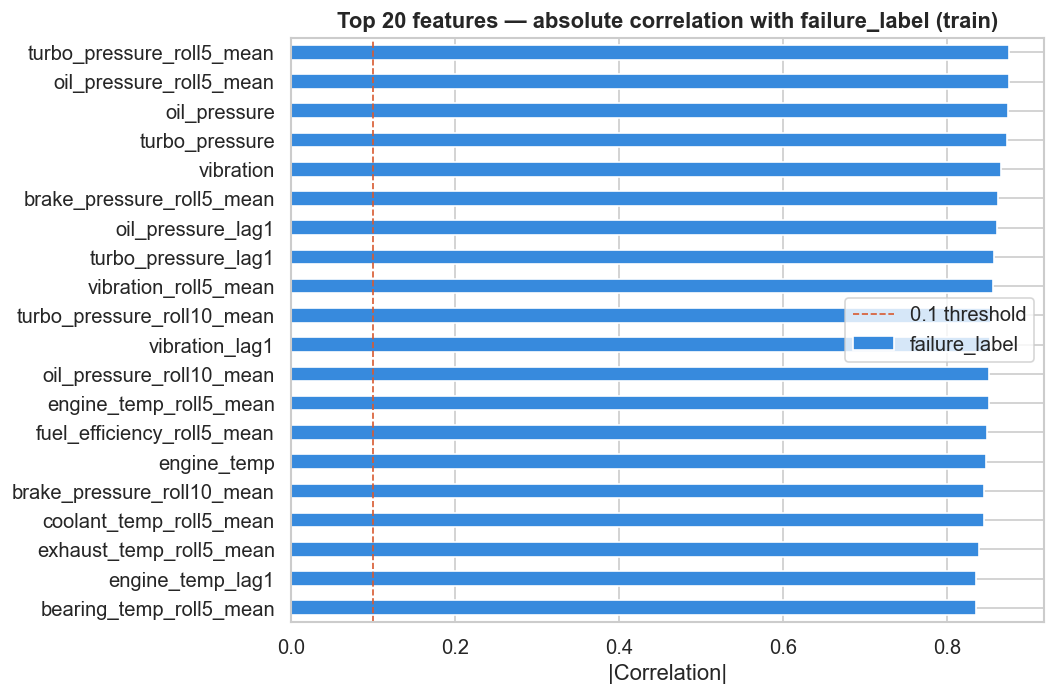

Saved → reports/figures/feature_correlations.png


In [12]:
corr_with_target = (
    train_df[FEATURE_COLS + [TARGET_COL]]
    .corr()[TARGET_COL].drop(TARGET_COL)
    .abs().sort_values(ascending=False).head(20)
)

fig, ax = plt.subplots(figsize=(9, 6))
corr_with_target.sort_values().plot.barh(ax=ax, color='#378ADD')
ax.set_title('Top 20 features — absolute correlation with failure_label (train)', fontweight='bold')
ax.set_xlabel('|Correlation|')
ax.axvline(0.1, color='#D85A30', linestyle='--', linewidth=1, label='0.1 threshold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_correlations.png')
plt.show()
print('Saved → reports/figures/feature_correlations.png')

---
## Cell 13 — Save all outputs

In [13]:
train_df.to_csv(PROCESSED_DIR / 'train.csv', index=False)
val_df.to_csv(PROCESSED_DIR   / 'val.csv',   index=False)
test_df.to_csv(PROCESSED_DIR  / 'test.csv',  index=False)

meta = {
    'feature_cols'     : FEATURE_COLS,
    'target_col'       : TARGET_COL,
    'sensor_cols'      : SENSOR_COLS,
    'scale_pos_weight' : scale_pos_weight,
    'train_locos'      : train_locos,
    'val_locos'        : val_locos,
    'test_locos'       : test_locos,
}
with open(PROCESSED_DIR / 'preprocessing_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved:')
print(f'  data/processed/train.csv               {len(train_df):,} rows')
print(f'  data/processed/val.csv                 {len(val_df):,} rows')
print(f'  data/processed/test.csv                {len(test_df):,} rows')
print(f'  data/processed/preprocessing_meta.json')
print(f'  models/scaler.pkl')

Saved:
  data/processed/train.csv               4,979 rows
  data/processed/val.csv                 802 rows
  data/processed/test.csv                1,144 rows
  data/processed/preprocessing_meta.json
  models/scaler.pkl


---
## Cell 14 — Phase 2 summary

In [14]:
print('=' * 60)
print('  PHASE 2 COMPLETE')
print('=' * 60)
print(f'  Final feature count    : {len(FEATURE_COLS)}')
print()
print('  Features added:')
print(f'    loco_age             : 1')
print(f'    Rolling (5+10 win)   : {len(rolling_cols_added)}')
print(f'    Lag (1 cycle)        : {len(lag_cols_added)}')
print(f'    One-hot encoded      : {len(new_ohe_cols)}')
print()
print('  Splits (no loco leakage):')
print(f'    Train  {len(train_locos)} locos  {len(train_df):,} rows  {train_df[TARGET_COL].mean()*100:.1f}% failure')
print(f'    Val    {len(val_locos)} locos   {len(val_df):,} rows  {val_df[TARGET_COL].mean()*100:.1f}% failure')
print(f'    Test   {len(test_locos)} locos   {len(test_df):,} rows  {test_df[TARGET_COL].mean()*100:.1f}% failure')
print()
print(f'  scale_pos_weight       : {scale_pos_weight}  <- use in Phase 3 XGBoost')
print()
print('  Next → 03_model_training.ipynb')
print('=' * 60)

  PHASE 2 COMPLETE
  Final feature count    : 86

  Features added:
    loco_age             : 1
    Rolling (5+10 win)   : 48
    Lag (1 cycle)        : 12
    One-hot encoded      : 10

  Splits (no loco leakage):
    Train  35 locos  4,979 rows  21.8% failure
    Val    7 locos   802 rows  27.1% failure
    Test   8 locos   1,144 rows  21.7% failure

  scale_pos_weight       : 3.59  <- use in Phase 3 XGBoost

  Next → 03_model_training.ipynb
